# K-Nearest Neighbors

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset, by hand](#1.-A-tiny-dataset,-by-hand)
2. [The real dataset: Breast Cancer](#2.-The-real-dataset:-Breast-Cancer)
3. [KNN at full scale](#3.-KNN-at-full-scale)
4. [Decision boundary and the effect of k](#4.-Decision-boundary-and-the-effect-of-k)
5. [Choosing k with cross-validation](#5.-Choosing-k-with-cross-validation)
6. [Distance metrics](#6.-Distance-metrics)
7. [Why scaling matters](#7.-Why-scaling-matters)
8. [Summary](#8.-Summary)

## 0. Introduction

Notebooks 1 and 2 built Logistic Regression: a model that learns an equation, `w` and `b`. This notebook asks a different question: what if we don't learn any equation at all?

K-Nearest Neighbors (KNN): to label a new point, look at its `k` closest training points and let them vote. This notebook does that by hand on 10 points, confirms it with `scikit-learn`, then moves to the real Breast Cancer dataset.

## 1. A tiny dataset, by hand

10 points, two classes, one new point to classify.

In [1]:
import numpy as np

X_toy = np.array([
    [1.0, 2.0], [1.5, 1.8], [1.2, 2.6], [2.0, 2.2], [0.8, 1.5],
    [4.5, 4.0], [5.0, 3.5], [4.2, 4.8], [5.5, 4.2], [4.8, 3.2],
])
y_toy = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # 0 = malignant-like, 1 = benign-like
query = np.array([3.0, 3.0])

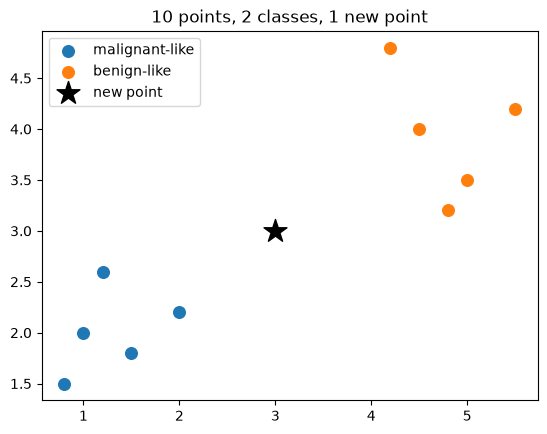

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1], label="malignant-like", s=70)
plt.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1], label="benign-like", s=70)
plt.scatter(*query, marker="*", s=300, color="black", label="new point")
plt.legend()
plt.title("10 points, 2 classes, 1 new point")
plt.show()

Euclidean distance from the new point to every training point:

In [3]:
distances = np.sqrt(((X_toy - query) ** 2).sum(axis=1))
order = np.argsort(distances)

In [4]:
import pandas as pd

neighbors = pd.DataFrame({
    "point": [tuple(p) for p in X_toy[order]],
    "class": y_toy[order],
    "distance": distances[order].round(2),
})
neighbors

,point,class,distance
0,"(2.0, 2.2)",0,1.28
1,"(4.5, 4.0)",1,1.80
2,"(4.8, 3.2)",1,1.81
3,"(1.2, 2.6)",0,1.84
4,"(1.5, 1.8)",0,1.92
5,"(5.0, 3.5)",1,2.06
6,"(4.2, 4.8)",1,2.16
7,"(1.0, 2.0)",0,2.24
8,"(0.8, 1.5)",0,2.66
9,"(5.5, 4.2)",1,2.77


Among the `k=5` nearest, majority vote. That's the entire rule:

In [5]:
k = 5
nearest_k_labels = y_toy[order[:k]]
vote = np.bincount(nearest_k_labels).argmax()
print("Votes among 5 nearest neighbors:", np.bincount(nearest_k_labels))
print("Predicted class:", vote)

Votes among 5 nearest neighbors: [3 2]
Predicted class: 0


Confirm with `scikit-learn`:

In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn_toy = KNeighborsClassifier(n_neighbors=5).fit(X_toy, y_toy)
print("KNeighborsClassifier prediction:", knn_toy.predict([query])[0])

KNeighborsClassifier prediction: 0


Same answer. Every `KNeighborsClassifier.predict()` call is exactly this, at any scale.

## 2. The real dataset: Breast Cancer

Same setup as notebook 2: load, split, scale.

In [7]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. KNN at full scale

Same rule as section 1, now on 455 real points across 30 scaled features instead of 10 points in 2D.

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [11]:
from sklearn.metrics import accuracy_score

y_pred_knn = knn.predict(X_test_scaled)
print(f"KNN (k=5) test accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

KNN (k=5) test accuracy: 0.9561


`fit` just stores the data, as in section 1. All the work happens in `predict`, a lazy learner, unlike Logistic Regression, which does its work upfront in `fit`.

## 4. Decision boundary and the effect of k

Synthetic 2D data (`make_moons`) makes the boundary visible, the same way notebook 2 used it.

In [12]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

In [13]:
def plot_boundary(ax, model, X, y, title, proba_thresh=0.5):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[proba_thresh], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="white", linewidths=0.6, s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

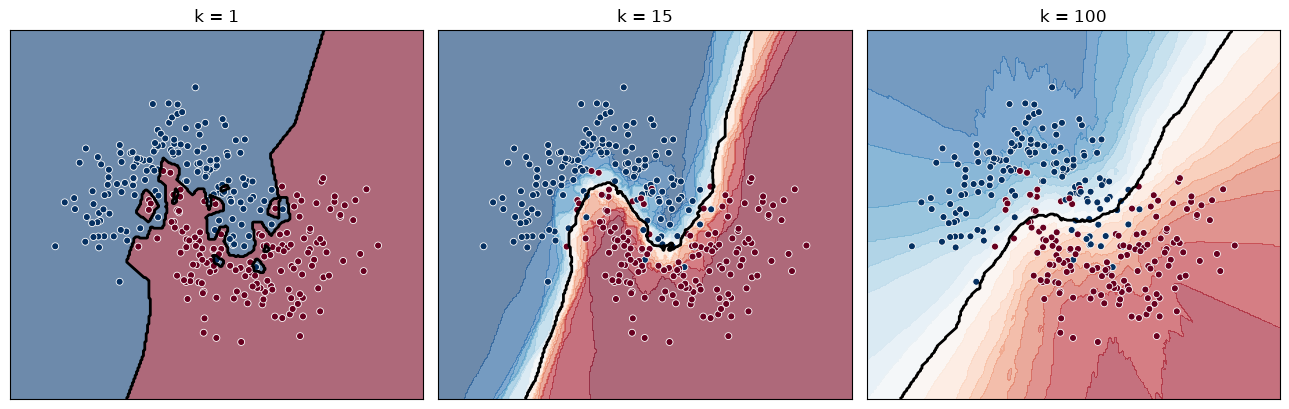

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, k in zip(axes, [1, 15, 100]):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_moons, y_moons)
    plot_boundary(ax, model, X_moons, y_moons, f"k = {k}")
plt.tight_layout()
plt.show()

`k=1` is jagged and chases noise: overfitting. `k=100` smooths into near-nothing: underfitting. `k` is KNN's complexity knob, playing the role `degree` played in week 3.

## 5. Choosing k with cross-validation

Same principle as choosing `alpha` or `degree` in week 3.

In [15]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]

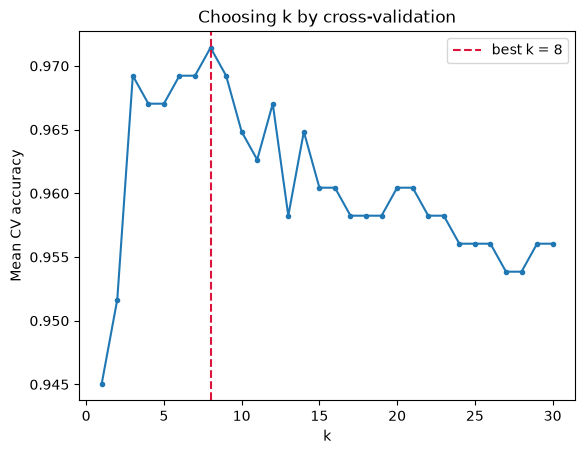

Best k: 8  (mean CV accuracy = 0.9714)


In [16]:
plt.plot(list(k_values), cv_scores, marker="o", markersize=3)
plt.axvline(best_k, color="crimson", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k")
plt.ylabel("Mean CV accuracy")
plt.title("Choosing k by cross-validation")
plt.legend()
plt.show()

print(f"Best k: {best_k}  (mean CV accuracy = {max(cv_scores):.4f})")

## 6. Distance metrics

Euclidean is straight-line distance, the default used above. Manhattan sums per-axis differences, like walking a city grid. A one-argument swap:

In [17]:
for metric in ["euclidean", "manhattan"]:
    model = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    print(f"{metric:>10}:  mean CV accuracy = {scores.mean():.4f}")

 euclidean:  mean CV accuracy = 0.9714
 manhattan:  mean CV accuracy = 0.9714


Close together here. `k` and scaling matter more than the distance formula.

## 7. Why scaling matters

Votes are decided by numeric distance. `mean area` ranges into the thousands, `mean smoothness` sits under 0.2. Unscaled, `area` alone would dominate:

In [18]:
print(X_train[["mean area", "mean smoothness"]].describe().loc[["min", "max"]])

     mean area  mean smoothness
min      143.5          0.06251
max     2499.0          0.14470


In [19]:
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
knn_scaled = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train)

In [20]:
print(f"KNN on raw features:    test accuracy = {accuracy_score(y_test, knn_unscaled.predict(X_test)):.4f}")
print(f"KNN on scaled features: test accuracy = {accuracy_score(y_test, knn_scaled.predict(X_test_scaled)):.4f}")

KNN on raw features:    test accuracy = 0.9298
KNN on scaled features: test accuracy = 0.9737


A real accuracy gap, not a hypothetical one. Logistic Regression tolerates unscaled features gracefully; KNN doesn't. `StandardScaler` before KNN is a default:

In [21]:
from sklearn.pipeline import make_pipeline

knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
accuracy_score(y_test, knn_pipeline.predict(X_test))

0.9736842105263158

## 8. Summary

- KNN takes a majority vote among `k` nearest neighbors, no equation, worked out by hand on 10 toy points before touching real data.
- A lazy learner: `fit` just stores data, all the work happens at `predict` time.
- `k` is the complexity knob: small `k` overfits, large `k` underfits. Chosen by cross-validation, same as `alpha` or `degree` in week 3.
- Feature scaling is not optional for KNN, unlike Logistic Regression.

Notebook 4 introduces a third, completely different approach, Decision Trees, starting the same way, on a tiny dataset first.